In [ ]:
%pip install ipywidgets

# Word Embeddings from Scratch: Skip-Gram Word2Vec

Word embeddings are dense vector representations of words that capture semantic and syntactic relationships from large text corpora. Rather than treating words as isolated symbols, embeddings place them in a continuous vector space where geometric relationships reflect meaning , *i.e* words used in similar contexts end up close together.

This notebook implements the **Skip-Gram Word2Vec** model from scratch, trained on the [Text8 corpus](http://mattmahoney.net/dc/text8.zip) — a cleaned Wikipedia extract of ~17 million tokens commonly used as a benchmark for word embedding models.

## Notebook Structure

1. **Data & Preprocessing** — loading Text8, tokenisation, vocabulary construction, and subsampling of frequent words
2. **Skip-Gram Training** — the Word2Vec skip-gram model with negative sampling, trained from scratch


### Load Text8 Dataset

This loads and unzips the Text8 corpus, decodes it, and splits it into a list of word tokens for later NLP use.

In [2]:
import urllib.request

# Download
urllib.request.urlretrieve("http://mattmahoney.net/dc/text8.zip", "../data/text8.zip")

import zipfile

# Unzip
with zipfile.ZipFile("../data/text8.zip") as f:
    text = f.read("text8").decode("utf-8")

# It's one long string, just split on spaces
tokens = text.split()

### Build Vocabulary for Skip-gram Preparation

The token list is cleaned by removing very short words, then a frequency count is computed for each remaining token. Words that occur too rarely are filtered out using a minimum frequency threshold, which helps reduce noise and keeps the vocabulary focused on meaningful patterns.

A vocabulary is then constructed from the remaining words and sorted by frequency. Each word is assigned a unique integer index, and reverse mappings are created to translate indices back into words.

This step is essential for Skip-gram modelling, where words must be represented as numerical IDs before training. The Skip-gram model learns relationships between words by predicting surrounding context words from a given target word, and these mappings provide the structure needed to convert raw text into training-ready input.

In [3]:
from collections import Counter

# Optional: remove very short tokens
tokens = [t for t in tokens if len(t) > 1]

word_count = Counter(tokens)

# Filter by minimum frequency instead of stopwords — more principled
min_count = 5
vocab = [w for w, c in word_count.items() if c >= min_count]
vocab = sorted(vocab, key=word_count.get, reverse=True)
vocab_size = len(vocab)
word_idx = {word: i for i, word in enumerate(vocab)}
idx_word = {i: word for i, word in enumerate(vocab)}

### Preparing Skip-gram Training Data

After building the vocabulary, the full token sequence is refined further to improve training quality for a Skip-gram model.

First, very short tokens are removed and rare words are filtered out using a minimum frequency threshold. This reduces noise and ensures that the model focuses on words with enough contextual information to learn meaningful relationships.

Next, a subsampling strategy is applied. Extremely common words (such as “the”, “and”, etc.) tend to dominate training data without adding much semantic value. To address this, each word is assigned a probability of being discarded based on its frequency. This step helps balance the dataset by reducing the influence of overly frequent terms.

The remaining tokens are then converted into numerical indices using the previously constructed vocabulary mapping. This transforms the text into a format suitable for machine learning models.

Finally, Skip-gram training pairs are generated using a sliding context window. For each target word, nearby words within a fixed window size are treated as context. These (target, context) pairs form the core training data used to teach the model how words relate to one another in context.

In [ ]:
from utils import generate_pairs
import random
import numpy as np

# Already have tokens from text.split() earlier
tokens = [t for t in text.split() if len(t) > 1]
word_count = Counter(tokens)

# Filter low frequency words
min_count = 5
vocab = [w for w, c in word_count.items() if c >= min_count]
vocab = sorted(vocab, key=word_count.get, reverse=True)
vocab_size = len(vocab)
word_idx = {word: i for i, word in enumerate(vocab)}
idx_word = {i: word for i, word in enumerate(vocab)}

# Subsampling probabilities
threshold = 1e-5
total_count = sum(word_count.values())
word_probs = {
    w: 1 - np.sqrt(threshold / (word_count[w] / total_count))
    for w in word_count
}

# Text8 is one big sequence, subsample and convert to indices
subsampled = [
    w for w in tokens
    if w in word_idx and random.random() > word_probs.get(w, 0)
]
sequence = [word_idx[w] for w in subsampled]

# Generate skip-gram pairs from the single sequence
window_size = 5
all_pairs = generate_pairs(sequence, window_size)

print(f"Total skip-gram pairs: {len(all_pairs)}")

Total skip-gram pairs: 46008410


### Unigram Distribution for Negative Sampling

A smoothed unigram distribution is constructed from the vocabulary frequencies. Each word frequency is raised to the power of 0.75 before normalisation, which reduces the dominance of very common words while still keeping them more likely to appear than rare ones.

This distribution is typically used in negative sampling for Skip-gram models. Instead of treating all words equally when selecting “noise” examples, more frequent words are sampled slightly more often, but in a softened way. This balance improves training stability and helps the model learn more robust word representations.

In [5]:
# Unigram distribution with smoothing (word2vec style)
word_freqs = np.array([word_count[idx_word[i]] for i in range(vocab_size)], dtype=np.float32)
unigram_dist = word_freqs**0.75
unigram_dist /= unigram_dist.sum()

### Skip-gram Training with Negative Sampling

This section implements the Skip-gram model trained using **negative sampling**, a computationally efficient approximation of the full softmax objective.

#### 1. Skip-gram Objective

For a given centre word $w_c$ and a true context word $w_o$, the model learns embeddings such that:

$
P(w_o \mid w_c) = \sigma\left(u_{w_o}^\top v_{w_c}\right)
$

where:
- $v_{w_c}$ is the embedding of the centre word,
- $u_{w_o}$ is the embedding of the context word,
- $\sigma(x) = \frac{1}{1 + e^{-x}}$ is the sigmoid function.

The goal is to maximise the probability of true context words while minimising the probability of unrelated words.

#### 2. Negative Sampling Idea

Instead of computing probabilities over the entire vocabulary (which is expensive), the model is trained to distinguish:

- **Positive pair**: real (centre, context) pairs from the data
- **Negative pairs**: randomly sampled “noise” words

For each positive pair $(w_c, w_o)$, $k$ negative samples $w_{n_i} \sim P_n(w)$ are drawn from a smoothed unigram distribution:

$
P_n(w) \propto f(w)^{0.75}
$

This introduces a controlled bias:
- frequent words are more likely to appear as negatives,
- but their influence is softened via exponent $0.75$.

#### 3. Loss Function

For one positive pair and $k$ negative samples, the objective is:

$
\mathcal{L} = - \log \sigma(u_{w_o}^\top v_{w_c}) - \sum_{i=1}^{k} \log \sigma(-u_{w_{n_i}}^\top v_{w_c})
$

This encourages:
- high similarity for true pairs,
- low similarity for noise pairs.

#### 4. Training Procedure

The implementation follows stochastic mini-batch gradient descent:

**Forward pass**

For a batch of centre-context pairs:
- compute positive scores:
$
\sigma(u_o^\top v_c)
$
- compute negative scores:
$
\sigma(-u_n^\top v_c)
$

**Backpropagation intuition**

Gradients push:
- $v_c$ closer to true context vectors,
- away from negative samples,
- context vectors updated similarly.

#### 5. Negative Sampling Mechanism

Negative samples are drawn using:

$
P_n(w) = \frac{f(w)^{0.75}}{\sum_w f(w)^{0.75}}
$

Each batch:
- samples $k$ negatives per context word,
- filters accidental positives,
- replaces missing samples if collisions occur.

#### 6. Parameter Updates

For each batch:
- embeddings are updated via SGD:
$
\theta \leftarrow \theta - \eta \nabla \mathcal{L}
$

where:
- $\eta$ is the learning rate,
- $\theta \in \{W_{in}, W_{out}\}$.

#### 7. Training Dynamics

The training loop:
- shuffles data each epoch,
- processes mini-batches,
- tracks loss:
$
\text{Loss} = \sum \mathcal{L}_{\text{batch}}
$
- applies learning rate decay,
- stores best-performing embeddings.

#### 8. Final Representation

After training:
- $W_{in}$ contains word embeddings (primary representation),
- $W_{out}$ acts as auxiliary context embeddings.

Typically, $W_{in}$ is used for downstream tasks such as:
- similarity search,
- clustering,
- analogy tasks,
- downstream ML models.

This completes the full Skip-gram with Negative Sampling (SGNS) training pipeline.

Epoch 1/20:   0%|          | 0/22465 [00:00<?, ?it/s]

Epoch 1/20 — Loss: 149160703.3509, LR: 0.03750


Epoch 2/20:   0%|          | 0/22465 [00:00<?, ?it/s]

Epoch 2/20 — Loss: 133480370.4974, LR: 0.03533


Epoch 3/20:   0%|          | 0/22465 [00:00<?, ?it/s]

...

Epoch 18/20 — Loss: 109005513.4196, LR: 0.00500


Epoch 19/20:   0%|          | 0/22465 [00:00<?, ?it/s]

Epoch 19/20 — Loss: 108918217.8457, LR: 0.00500


Epoch 20/20:   0%|          | 0/22465 [00:00<?, ?it/s]

Epoch 20/20 — Loss: 108851257.3661, LR: 0.00500

Best loss: 108851257.3661 at epoch 20


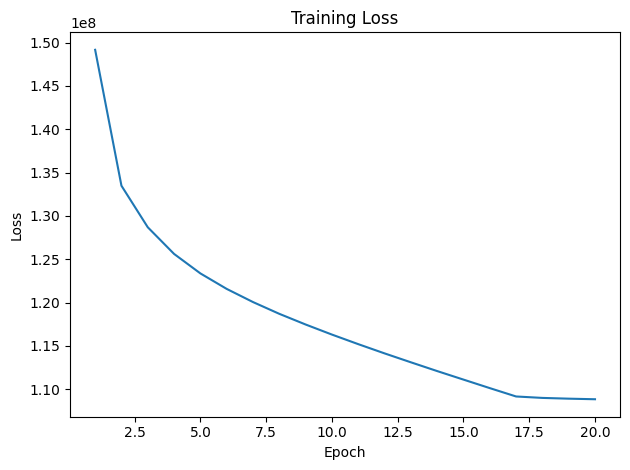

In [6]:
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from utils import get_negative_samples_batch, sigmoid


def train(pairs, W_in, W_out, epochs=5, learning_rate=0.05, k=5, batch_size=4096):
    pairs = np.array(pairs)
    lr = learning_rate
    loss_history = []
    best_loss = float('inf')
    best_W_in, best_W_out = W_in.copy(), W_out.copy()
    best_epoch = 1

    for epoch in range(epochs):
        np.random.shuffle(pairs)
        total_loss = 0.0
        num_batches = len(pairs) // batch_size

        for b in tqdm(range(num_batches), desc=f"Epoch {epoch+1}/{epochs}"):
            
            batch = pairs[b * batch_size:(b + 1) * batch_size]
            centers = batch[:, 0]
            contexts = batch[:, 1]

            neg_samples = get_negative_samples_batch(contexts, vocab_size, unigram_dist,  k)

            v_c  = W_in[centers]
            u_o  = W_out[contexts]
            u_ks = W_out[neg_samples]

            # Positive loss
            pos_score = sigmoid(np.einsum('bd,bd->b', u_o, v_c))
            pos_score = np.clip(pos_score, 1e-10, 1 - 1e-10)
            loss_pos  = -np.log(pos_score).sum()

            # Negative loss
            neg_scores = sigmoid(-np.einsum('bkd,bd->bk', u_ks, v_c))
            neg_scores = np.clip(neg_scores, 1e-10, 1 - 1e-10)
            loss_neg   = -np.log(neg_scores).sum()

            # Gradients
            d_pos = (pos_score - 1)
            d_neg = (1 - neg_scores)

            grad_v_c  = (d_pos[:, None] * u_o +
                         np.einsum('bk,bkd->bd', d_neg, u_ks))
            grad_u_o  = d_pos[:, None] * v_c
            grad_u_ks = d_neg[:, :, None] * v_c[:, None, :]

            np.add.at(W_in,  centers,     -lr * grad_v_c)
            np.add.at(W_out, contexts,    -lr * grad_u_o)
            np.add.at(W_out, neg_samples, -lr * grad_u_ks)

            total_loss += loss_pos + loss_neg

        # Learning rate decay
        if lr > 0.005:
            lr = learning_rate - (learning_rate - 0.005)*epoch*4/(epochs*3)

        loss_history.append(total_loss)
        print(f"Epoch {epoch+1}/{epochs} — Loss: {total_loss:.4f}, LR: {lr:.5f}")

        if total_loss < best_loss:
            best_loss = total_loss
            best_epoch = epoch + 1
            best_W_in  = W_in.copy()
            best_W_out = W_out.copy()

    print(f'\nBest loss: {best_loss:.4f} at epoch {best_epoch}')
    plt.plot(range(1, len(loss_history) + 1), loss_history)
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Loss')
    plt.tight_layout(); plt.show()

    return best_W_in, best_W_out

embedding_dim = 256
W_in  = np.random.randn(vocab_size, embedding_dim) * 0.5/embedding_dim
W_out = np.random.randn(vocab_size, embedding_dim) * 0.5/embedding_dim

W_in, W_out = train(all_pairs, W_in, W_out, epochs=20, learning_rate=0.0375, k=12, batch_size=2048)

### Vocabulary Filtering via WordNet Lemmatisation

Before proceeding to downstream evaluation and analogy tasks, a filtered embedding vocabulary is constructed to retain only **canonical base forms** (lemmas) as defined by WordNet.

#### Motivation

The raw vocabulary constructed from the corpus will inevitably contain noise such as misspellings, inflected forms (e.g. *running*, *cats*), proper nouns, and other tokens that are not semantically grounded in a lexical resource. Retaining such tokens introduces two problems:

1. **Evaluation noise** — analogy and similarity benchmarks assume clean, base-form vocabulary entries. Inflected or spurious tokens can skew results unpredictably.
2. **Redundancy** — multiple surface forms of the same word (e.g. *run*, *runs*, *ran*) occupy separate embedding rows, diluting the representational signal.

#### Filtering Criteria

A word is retained if and only if it satisfies **both** of the following conditions:

| Criterion | Description |
|---|---|
| Present in WordNet | The token appears as a lemma in at least one WordNet synset, confirming it is a recognised English word |
| Morphological base form | `wn.morphy(w) == w` — the word is its own morphological root, ensuring inflected forms are excluded |

#### Effect

Only the subset of the trained `W_in` embedding matrix corresponding to these filtered words is carried forward. Index mappings (`filtered_word_idx`, `filtered_idx_word`) are rebuilt over this reduced vocabulary, which is used for all subsequent similarity and analogy evaluations.

In [7]:
import nltk

nltk.data.path.append('../data/')
nltk.download('wordnet', download_dir='../data/')

from nltk.corpus import wordnet as wn

lemmas = {lemma.name().lower()
          for synset in wn.all_synsets()
          for lemma in synset.lemmas()
          if lemma.name().isalpha() and lemma.name().islower()}

clean_lemmas = {w for w in lemmas if wn.morphy(w) == w}

# Words that are in both your embeddings and WordNet lemmas
filtered_words = [w for w in word_idx if w in clean_lemmas]

# Get their original indices and extract embedding rows
filtered_indices = [word_idx[w] for w in filtered_words]
W_filtered = W_in[filtered_indices]  # shape: (len(filtered_words), 256)

# Rebuild index mappings
filtered_word_idx = {w: i for i, w in enumerate(filtered_words)}
filtered_idx_word = {i: w for i, w in enumerate(filtered_words)}

print(f"Original vocab size: {len(word_idx)}")
print(f"Filtered vocab size: {len(filtered_words)}")

[nltk_data] Downloading package wordnet to ../data/...


Original vocab size: 71264
Filtered vocab size: 24270


### Persisting Embeddings and Vocabulary Mappings

The trained embeddings and their associated vocabulary mappings are serialised to disk under `artefacts/` so that downstream notebooks can load them directly without retraining.

#### Artefacts Written

| File | Contents |
|---|---|
| `filtered_word_idx.json` | `word → index` mapping for the filtered (WordNet) vocabulary |
| `filtered_idx_word.json` | `index → word` mapping for the filtered vocabulary |
| `filtered_embeddings.npz` | Input embedding matrix `W_in` restricted to filtered vocabulary — shape `(filtered_vocab, 256)` |
| `word_idx.json` | `word → index` mapping for the full training vocabulary |
| `idx_word.json` | `index → word` mapping for the full training vocabulary |
| `skipgram_embeddings.npz` | Full input embedding matrix `W_in` — shape `(vocab, 256)` |

#### Notes

- Embedding matrices are cast to `float32` before saving to halve storage relative to `float64`, with no meaningful loss of precision for similarity computations.
- The `.npz` format stores the matrix under the key `W`; load it downstream with `np.load(path)["W"]`.
- Both the full and filtered artefacts are retained so that experiments can be run against either vocabulary without rerunning training.

In [8]:
import json

#Filtered
with open("../artefacts/filtered_word_idx.json", "w") as f:
    json.dump(filtered_word_idx, f)

with open("../artefacts/filtered_idx_word.json", "w") as f:
    json.dump(filtered_idx_word, f)
    
np.savez(
    "../artefacts/filtered_embeddings.npz",
    W= W_filtered.astype(np.float32)
)

#Full 
with open("../artefacts/word_idx.json", "w") as f:
    json.dump(word_idx, f)

with open("../artefacts/idx_word.json", "w") as f:
    json.dump(idx_word, f)
    
np.savez(
    "../artefacts/skipgram_embeddings.npz",
    W= W_in.astype(np.float32)
)